In [1]:
import warnings
warnings.filterwarnings('ignore')


In [2]:
# les données climatiques sont volumineuses (un fichier par département)
# pour ne pas les télécharger à la main, on crée un programme pour les importer automatiquement 
# en sélectionnant uniquement les variables d'intérêt

import pandas as pd
import numpy as np

# pour chaque département, on va procéder de la même façon
# on crée donc une fonction qui prend le département comme argument

def agreg_dpt(DEP):
    url = "https://object.files.data.gouv.fr/meteofrance/data/synchro_ftp/BASE/MENS/MENSQ_" + DEP + "_previous-1950-2023.csv.gz"
    df=pd.read_csv(url, sep=";")
    df_filtre = df[['NOM_USUEL', "AAAAMM","TM", "TX","RR", "UMM", "FFM", "TXMIN", "NBJTX0", "NBJTX25", "NBJTX30", "NBJTX35","NBJNEIG", "NBJSOLNG"]]
# on crée une variable ne contenant que l'annee 
    df_filtre['AAAA'] = df_filtre['AAAAMM'].astype(str).str[:4].astype(int)
    df_filtre['MM']= df_filtre['AAAAMM'].astype(str).str[5:6].astype(int)
# on sélectionne nos mois et années d'intérêt
    df_filtre = df_filtre[df_filtre.AAAA.isin(list(range(2011, 2022)))]
    df_filtre = df_filtre[df_filtre.MM.isin([1,2,3,6,7,8,9,12])]
# on calcule la moyenne départementale pour toutes les variables
    df_filtre['TX_num']=df_filtre.TX.astype("float64")
    df_filtre['TXMIN_num']=df_filtre.TXMIN.astype("float64")
    df_filtre = df_filtre.groupby(['AAAA','MM'])[["TM", "TX_num","RR", "UMM", "FFM", "TXMIN_num", "NBJTX0", "NBJTX25", "NBJTX30", "NBJTX35","NBJNEIG", "NBJSOLNG"]].mean()
    df_filtre['DEP'] = DEP
    return(df_filtre)

# on prépare une boucle pour importer un à un les fichiers départements
# et concaténer les outputs de la fonction agreg_dpt
liste_dep = np.arange(2,96)
df = agreg_dpt("01")
for i in liste_dep:
    num = f'{i:02}'
    df = pd.concat([df, agreg_dpt(num)])

# on remet année et mois (devenues index) en variables normales
df = df.reset_index() 

# saison (été ou hiver)
conditions1 = [
    (df['MM'] <= 3) | (df['MM'] == 12),
    (df['MM'] >= 6) & (df['MM'] <= 9)
    ]

values1 = ['hiver', 'été']

df['saison'] = np.select(conditions1, values1, default='Other')

# période (avant ou après 2015)
conditions2 = [
    (df['AAAA'] <= 2015),
    (df['AAAA'] > 2015)
    ]

values2 = ['avant_2015', 'apres_2015']

df['periode'] = np.select(conditions2, values2, default='Other')

# pour tester : évolution moyenne l'été dans les bouches du rhone entre avant 2015 vs apres 2015
df[df['DEP']=="13"].groupby(['saison', 'periode'])['NBJTX30'].mean()

base_temp = df
base_temp.head()

,AAAA,MM,TM,TX_num,RR,UMM,FFM,TXMIN_num,NBJTX0,NBJTX25,NBJTX30,NBJTX35,NBJNEIG,NBJSOLNG,DEP,saison,periode
0,2011,1,5.120833,8.958333,57.742353,87.222222,1.584615,1.014583,2.395833,0.000,0.000000,0.000000,2.206897,1.0,01,hiver,avant_2015
1,2011,2,4.340426,7.976596,153.012941,87.222222,1.676923,-0.595745,1.021277,0.000,0.000000,0.000000,4.355556,1.0,01,hiver,avant_2015
2,2011,3,7.730435,13.321739,58.152381,75.666667,1.850000,3.939130,0.043478,0.000,0.000000,0.000000,0.000000,0.0,01,hiver,avant_2015
3,2011,6,17.520833,23.425000,111.425581,73.222222,2.050000,12.158333,0.000000,11.875,2.791667,0.250000,0.000000,0.0,01,été,avant_2015
4,2011,7,17.183333,23.208333,145.258140,73.333333,2.016667,17.208333,0.000000,10.500,1.916667,0.041667,0.000000,0.0,01,été,avant_2015


In [3]:
import pandas as pd
import numpy as np

colonnes_a_conserver = [
    'FREQ', 
    'GEO', 
    'GEO_OBJECT',
    'TERRTYPO',
    'TOUR_MEASURE',
    'TOUR_RESID',
    'CONF_STATUS',
    'DECIMALS',
    'OBS_STATUS',
    'OBS_STATUS_FR',
    'UNIT_MULT',
    'TIME_PERIOD',
    'OBS_VALUE'
]


import requests 
url = "https://www.data.gouv.fr/api/1/datasets/r/1129fd80-2564-452c-86d4-9e36e7cca4a5"
dossier = requests.get(url)

import zipfile
import io

# Ouvrir le contenu ZIP en mémoire
z = zipfile.ZipFile(io.BytesIO(dossier.content))

# Extraire tous les fichiers
z.extractall("donnees_zip")

import pandas as pd
import os

fichiers = [f for f in os.listdir("donnees_zip") if f.endswith(".csv")]
df = pd.read_csv(os.path.join("donnees_zip", fichiers[1]), sep = ';', usecols=colonnes_a_conserver)


# on enlève les colonnes UNIT_LOC_RANKING (Classement de l’établissement touristique)
# ACTIVITY (Catégorise le type d’hébergement touristique.) 
# HOTEL_STA (Statut d’appartenance de l’établissement hôtelier.)

df["OBS_VALUE_CORR"] = df["OBS_VALUE"] * (10 ** df["UNIT_MULT"])
# on applique le facteur d'échelle 

df.loc[df["OBS_VALUE_CORR"].notna(), "OBS_VALUE_CORR"] = df.loc[df["OBS_VALUE_CORR"].notna()].apply(
    lambda x: round(x["OBS_VALUE_CORR"], int(x["DECIMALS"])),
    axis=1
)
# on met le bon nombre de décimals 

df = df.drop(columns=["DECIMALS", "UNIT_MULT", "OBS_VALUE"])
# on garde seulement la valeur observée qui est corrigée

df = df.loc[df['TOUR_MEASURE'].isin(["ARR"])]
# on choisit le nombre d'arrivée comme indicateur

df = df.loc[df['OBS_STATUS'].isin(["A", "P"])]
# on exclut les valeurs manquantes (O), A= Normale (définitive/validée), P= Valeur provisoire
# en faisant: print(df["OBS_STATUS"].value_counts(dropna=False))
# on obtient OBS_STATUS; A 69627; Name: count, dtype: int64
# il n'y a donc pas de P, on va pouvoir supprimer la colonne OBS_STATUS

df = df.drop(columns=["OBS_STATUS"])

# on remarque que certaines valeurs définitives sont marquées Prov sous OBS_STATUS_FR
# A = valeur correcte du point de vue technique,
# mais OBS_STATUS_FR = "PROV" = pas encore consolidée statistiquement.

# en faisant: print(df["CONF_STATUS"].value_counts(dropna=False))
# on obtient CONF_STATUS; F 69627; Name: count, dtype: int64
# il n'y a donc que des observations diffusables, on va pouvoir supprimer la colonne CONF_STATUS

df = df.drop(columns=["CONF_STATUS","TOUR_MEASURE","OBS_STATUS_FR"])

# On définit les années que l'on veut garder
annees_cibles = np.array([x for x in range(2011, 2022)]).astype(str)

# On garde les lignes où TIME_PERIOD commence par 2011 à 2021
df = df[df["TIME_PERIOD"].astype(str).str.startswith(tuple(annees_cibles))]
df = df.sort_values("TIME_PERIOD", ascending = False)

# On prend les données mensuelles et on supprime la colonne FREQ
df = df.loc[df['FREQ'].isin(["M"])]
df = df.drop("FREQ", axis = 1)

# on crée une variable ne contenant que l'annee et une autre le mois
df['AAAA'] = df['TIME_PERIOD'].astype(str).str[:4].astype(int)
df['MM']= df['TIME_PERIOD'].astype(str).str[5:7].astype(int)
df = df.drop("TIME_PERIOD", axis = 1)

# On prend les données de departement et on supprime c
df = df.loc[df['GEO_OBJECT'].isin(["DEP"])]
df = df.drop("GEO_OBJECT", axis = 1)

# on supprime TERRTYPO car tout est identique
df = df.drop("TERRTYPO", axis = 1)

#changer le nom de la colonne GEO en DEP pour la fusion
col = df.columns.tolist()
col[0] = "DEP"
df.columns = col

base_touri = df
print(base_touri.head(10))

       DEP TOUR_RESID  OBS_VALUE_CORR  AAAA  MM
173047  50        250         31520.0  2021  12
135687  48         _T          5820.0  2021  12
41213   56    1_X_250          1560.0  2021  12
138378  83         _T         69830.0  2021  12
183266  18        250         25250.0  2021  12
38003   71    1_X_250          9460.0  2021  12
31889   50    1_X_250          3150.0  2021  12
119729  67         _T        223430.0  2021  12
140903  47         _T         16000.0  2021  12
135497  37         _T         59510.0  2021  12


In [4]:
base =  pd.merge(base_temp, base_touri, on=["DEP", "AAAA", "MM"], how="inner").drop_duplicates()

col = base.columns.tolist()
col[2], col[14] = col[14], col[2]
base = base[col]
base.head()

,AAAA,MM,DEP,TX_num,RR,UMM,FFM,TXMIN_num,NBJTX0,NBJTX25,NBJTX30,NBJTX35,NBJNEIG,NBJSOLNG,TM,saison,periode,TOUR_RESID,OBS_VALUE_CORR
0,2011,1,01,8.958333,57.742353,87.222222,1.584615,1.014583,2.395833,0.0,0.0,0.0,2.206897,1.0,5.120833,hiver,avant_2015,_T,47330.0
1,2011,1,01,8.958333,57.742353,87.222222,1.584615,1.014583,2.395833,0.0,0.0,0.0,2.206897,1.0,5.120833,hiver,avant_2015,1_X_250,7410.0
2,2011,1,01,8.958333,57.742353,87.222222,1.584615,1.014583,2.395833,0.0,0.0,0.0,2.206897,1.0,5.120833,hiver,avant_2015,250,39910.0
3,2011,2,01,7.976596,153.012941,87.222222,1.676923,-0.595745,1.021277,0.0,0.0,0.0,4.355556,1.0,4.340426,hiver,avant_2015,1_X_250,9540.0
4,2011,2,01,7.976596,153.012941,87.222222,1.676923,-0.595745,1.021277,0.0,0.0,0.0,4.355556,1.0,4.340426,hiver,avant_2015,_T,53900.0


# Quelques Stats Des

In [5]:
df = base[base["TOUR_RESID"] == "_T"].drop("TOUR_RESID", axis =1)
df[df.columns[2:]].describe()

,TX_num,RR,UMM,FFM,TXMIN_num,NBJTX0,NBJTX25,NBJTX30,NBJTX35,NBJNEIG,NBJSOLNG,TM,OBS_VALUE_CORR
count,6575.000000,6580.000000,6425.000000,6437.000000,6575.000000,6575.000000,6575.000000,6575.000000,6575.000000,6228.000000,3286.000000,6574.000000,6.580000e+03
mean,19.072176,70.003008,75.293967,3.047165,11.876194,0.379116,8.630779,3.056985,0.490194,0.960516,0.478536,13.933261,1.034448e+05
std,7.506959,39.350132,8.401488,0.797991,7.424571,1.136456,8.871403,4.432262,1.125737,1.844390,1.614804,6.434770,1.451712e+05
min,0.604878,0.000000,49.111111,1.300000,-8.793293,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-3.516667,3.530000e+03
25%,11.370943,42.172155,69.363636,2.470000,4.589502,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.495515,3.145750e+04
50%,21.884783,65.167929,75.571429,2.925000,14.820833,0.000000,6.750000,0.848485,0.000000,0.000000,0.000000,16.607263,6.404500e+04
75%,25.170175,90.896429,81.375000,3.507143,17.824405,0.038462,15.730769,4.800000,0.307692,1.235294,0.000000,19.204087,1.326150e+05
max,32.939286,416.483696,93.869565,7.534211,28.803571,12.981707,30.968750,27.117647,9.342105,14.000000,18.250000,25.814286,1.587790e+06


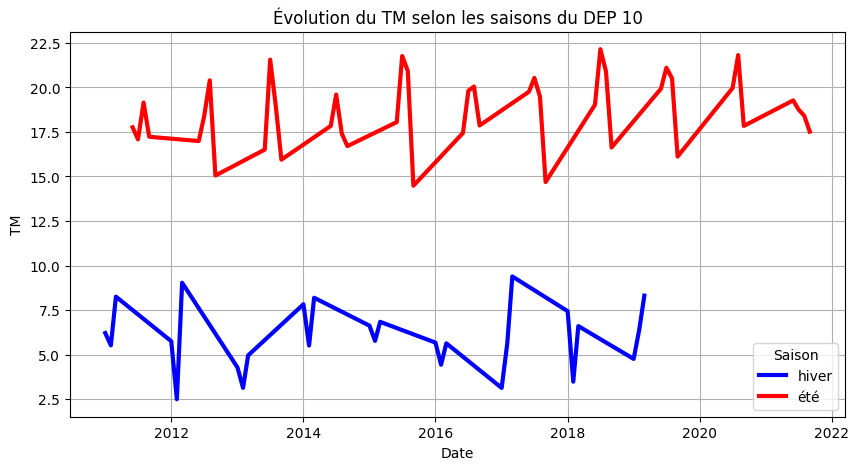

In [6]:
df = base[base["TOUR_RESID"] == "_T"].drop("TOUR_RESID", axis =1)
df["date"] = pd.to_datetime(df["AAAA"].astype(str) + "-" + df["MM"].astype(str) + "-01")
df = df.set_index("date").sort_index()
df = df.drop(["AAAA","MM"], axis = 1)[df.DEP == "10"]


import matplotlib.pyplot as plt

couleurs = {
    "hiver": "blue",
    "été": "red"
}

plt.figure(figsize=(10, 5))

for saison, sous_base in df.groupby("saison"):
    plt.plot(sous_base.index, sous_base["TM"],
             color=couleurs[saison],
             linewidth=3,
             label=saison)

plt.title("Évolution du TM selon les saisons du DEP 10")
plt.xlabel("Date")
plt.ylabel("TM")
plt.legend(title="Saison")
plt.grid(True)
plt.show()


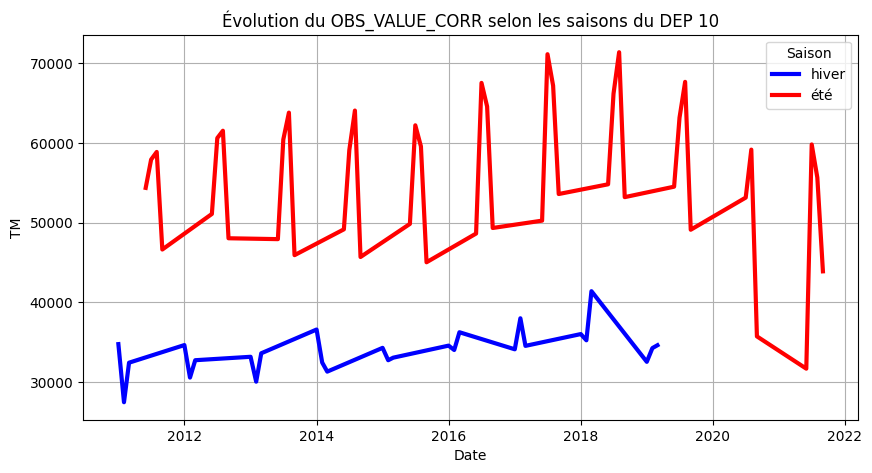

In [7]:
df = base[base["TOUR_RESID"] == "_T"].drop("TOUR_RESID", axis =1)
df["date"] = pd.to_datetime(df["AAAA"].astype(str) + "-" + df["MM"].astype(str) + "-01")
df = df.set_index("date").sort_index()
df = df.drop(["AAAA","MM"], axis = 1)[df.DEP == "10"]


import matplotlib.pyplot as plt

couleurs = {
    "hiver": "blue",
    "été": "red"
}

plt.figure(figsize=(10, 5))

for saison, sous_base in df.groupby("saison"):
    plt.plot(sous_base.index, sous_base["OBS_VALUE_CORR"],
             color=couleurs[saison],
             linewidth=3,
             label=saison)

plt.title("Évolution du OBS_VALUE_CORR selon les saisons du DEP 10")
plt.xlabel("Date")
plt.ylabel("TM")
plt.legend(title="Saison")
plt.grid(True)
plt.show()


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 70 entries, 2011-01-01 to 2021-09-01
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   DEP             70 non-null     object 
 1   TX_num          70 non-null     float64
 2   RR              70 non-null     float64
 3   UMM             70 non-null     float64
 4   FFM             70 non-null     float64
 5   TXMIN_num       70 non-null     float64
 6   NBJTX0          70 non-null     float64
 7   NBJTX25         70 non-null     float64
 8   NBJTX30         70 non-null     float64
 9   NBJTX35         70 non-null     float64
 10  NBJNEIG         70 non-null     float64
 11  NBJSOLNG        44 non-null     float64
 12  TM              70 non-null     float64
 13  saison          70 non-null     object 
 14  periode         70 non-null     object 
 15  OBS_VALUE_CORR  70 non-null     float64
dtypes: float64(13), object(3)
memory usage: 9.3+ KB


# Taux de croissance de la temperarture moyenne par departement

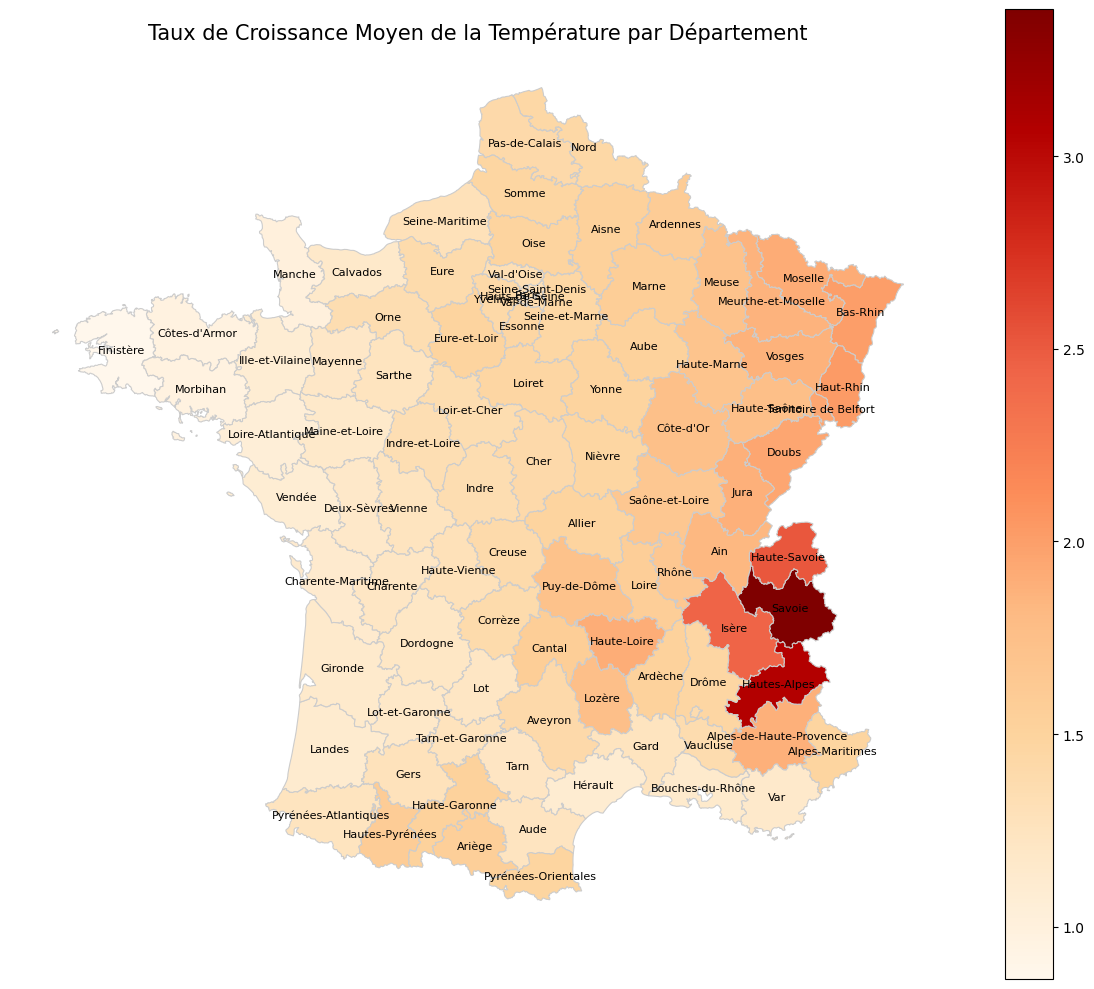

In [9]:
base1 = base[base["TOUR_RESID"] == "_T"].drop("TOUR_RESID", axis =1)


def tcm(valeurs):
    n = len(valeurs)
    if n < 2:
        return None
    taux = (valeurs.iloc[-1] / valeurs.iloc[0]) ** (1 / (n - 1)) - 1
    return taux * 100

dep = base.DEP.unique()
tcm_list = [tcm(base1[base1["DEP"] == x].TM) for x in dep]
df = pd.DataFrame(data={"code": dep, "TCM": tcm_list})

import geopandas as gpd
import matplotlib.pyplot as plt

# Charger les départements français depuis une source publique
url = "https://france-geojson.gregoiredavid.fr/repo/departements.geojson"
gdf = gpd.read_file(url)


carte = gdf.merge(df, on=["code"], how="inner")



# 5. Afficher la carte avec les noms des départements
fig, ax = plt.subplots(figsize=(12, 10))
carte.plot(column='TCM', cmap='OrRd', linewidth=0.8, ax=ax, edgecolor='0.8', legend=True)

# Ajouter les noms des départements
for idx, row in carte.iterrows():
    centroid = row['geometry'].centroid
    ax.text(centroid.x, centroid.y, row['nom'], fontsize=8, ha='center', va='center')

ax.set_title("Taux de Croissance Moyen de la Température par Département", fontsize=15)
ax.axis('off')
plt.tight_layout()
plt.show()



# Indice TCI

In [10]:
base1 = base[base["TOUR_RESID"] == "_T"].drop("TOUR_RESID", axis =1).dropna()
base1["TCI"] = 2*base1.TM + 5*base1.TX_num + 2*base1.RR + base1.UMM + base1.FFM


import numpy as np

q25 = np.quantile(base1['TCI'], 0.25)
q50 = np.quantile(base1.TCI, 0.50)
q75 = np.quantile(base1.TCI, 0.75)

conditions2 = [
    (base1.TCI <= q25),
    ((base1.TCI >= q25) & (base1.TCI < q50)),
    ((base1.TCI >= q50) & (base1.TCI < q75)),
    (base1.TCI >= q75)
]
values2 = ["Défavorable", "Acceptable", "Favorable", "Idéale"]
base1['TCI'] = np.select(conditions2, values2, default='Autre')

tab = pd.crosstab(base1.saison, base1.TCI, normalize = "columns")
tab

TCI,Acceptable,Défavorable,Favorable,Idéale
saison,,,,
hiver,0.380952,0.758242,0.294261,0.296703
été,0.619048,0.241758,0.705739,0.703297


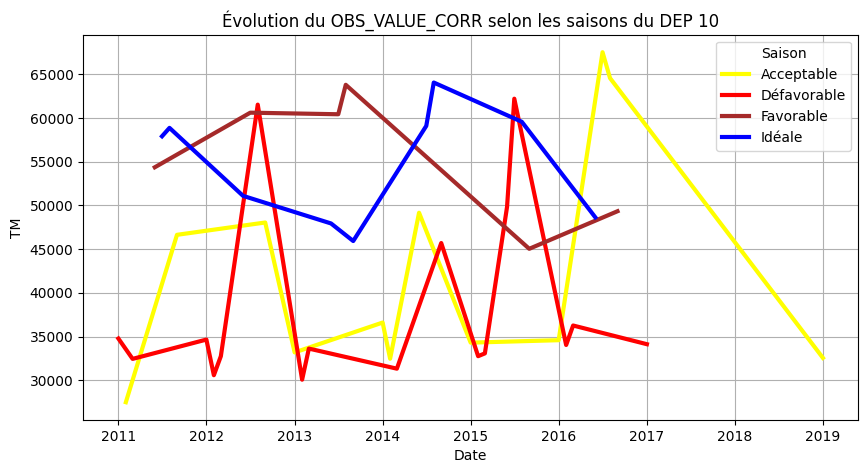

In [11]:
df = base1
df["date"] = pd.to_datetime(df["AAAA"].astype(str) + "-" + df["MM"].astype(str) + "-01")
df = df.set_index("date").sort_index()
df = df.drop(["AAAA","MM"], axis = 1)[df.DEP == "10"]


couleurs = {
    "Défavorable": "red",
    "Acceptable": "yellow",
    "Favorable": "brown",
    "Idéale": "blue"
}

plt.figure(figsize=(10, 5))

for saison, sous_base in df.groupby("TCI"):
    plt.plot(sous_base.index, sous_base["OBS_VALUE_CORR"],
             color=couleurs[saison],
             linewidth=3,
             label=saison)

plt.title("Évolution du OBS_VALUE_CORR selon les saisons du DEP 10")
plt.xlabel("Date")
plt.ylabel("TM")
plt.legend(title="Saison")
plt.grid(True)
plt.show()
